## Object detection with YOLOv3

Yolo needs OpenCV to work with images. 

In [1]:
!pip install matplotlib
!pip install numpy
!pip install opencv-python
!pip install --upgrade opencv-python

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

We first load the weights, config files and COCO classes (mouse, chair, car, person...) associated to the pretrained model.

In [3]:
yolo = cv2.dnn.readNet("yolov3.weights", "yolov3.cfg")
yolo

< cv2.dnn.Net 0x7f0edb916bf0>

In [4]:
classes = []
with open("coco.names","r") as file:
    classes = [line.strip() for line in file.readlines()]
    


Extract the layer names and output layers from the pre-trained YOLO model

In [5]:
layer_names = yolo.getLayerNames()
outputlayers = [layer_names[i -1] for i in yolo.getUnconnectedOutLayers()]


In [6]:
# loading the image
name = "image.jpg"
img = cv2.imread(name)
height, width, channels = img.shape

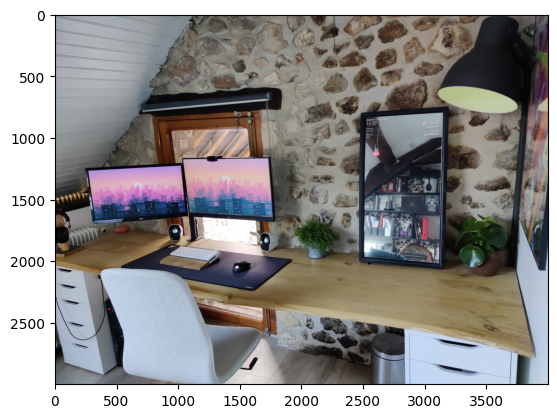

In [7]:
plt.imshow(img[:,:,::-1])
plt.show()

Once the image loaded, we want to convert it into a BLOB (Binary Large Object). A Blob is a special format used by OpenCV to “normalize” images, audio, or video data

In [8]:
blob = cv2.dnn.blobFromImage(img, 1 / 255.0, (416, 416), swapRB=True, crop=False)

We set the blob as YOLO input and forward the output layers to it.

In [9]:
yolo.setInput(blob)

The outputs represent all matches between the blobs and classes names. 

In [10]:
outputs = yolo.forward(outputlayers)

The next step is to loop through the outputs and determine the bounding boxes coordinates with the highest confidence and their associated classes ids:

In [11]:
class_ids = []
confidences = []
boxes = []
for output in outputs:
    for detection in output:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        
        if (confidence > 0.5):
            # Object Detected
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)
            
            # Rectangle Coordinates
            x = int(center_x - w/2)
            y = int(center_y - h/2)
            
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

Using the boxes and confidence coefficients previously computed, we can determine their indices and set random colors to the classes names:

In [12]:
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)
colors = np.random.uniform(0, 255, size=(len(classes), 3))


Also in above code ve have used NMS (Non-maximum Suppression) by using this we ensure that there are no multiple detections of the same image.

**NMS Uses the “Intersection over Union” (IoU)**

So, to implement non-max suppression, first we have to select the box with the highest score, and then we remove boxes that overlap, and again select the box with the highest score. In this way we will be able to remove all the unwanted boxes, and only the best boxes will remain that consist of our objects.

The last step is looping through the indices to draw the bounding boxes using the random colors set previously and the labels being the classes names. We can change the font and customize it as needed. Everything will be drawn to the image we set at the beginning.

In [13]:
colorGreen = (0, 255, 0)

list = []

for i in range(len(boxes)):
    if i in indices:
        x, y, w, h = boxes[i]
        
         # draw a bounding box rectangle and label on the image
        color = [int(c) for c in colors[class_ids[i]]]
        text = f"{classes[class_ids[i]]}: {confidences[i]:.2f}"
               
        start = (x,y)
        end = (x+w,y+h)
        
        cv2.rectangle(img, start, end, color = color, thickness = 4) 
        
                                               
        cv2.putText(img, text, (x,y-20), cv2.FONT_HERSHEY_PLAIN, 5, colors[1], 4)
        
        list.append(classes[class_ids[i]])
        
        
        print(f"{classes[class_ids[i]]}: {boxes[i]}")

tvmonitor: [255, 1188, 793, 603]
chair: [289, 2042, 1541, 939]
tvmonitor: [1058, 1151, 723, 628]
pottedplant: [1952, 1627, 322, 367]
keyboard: [895, 1874, 461, 145]
mouse: [1443, 2010, 139, 83]


The new image is created with bouding boxes and object class names.

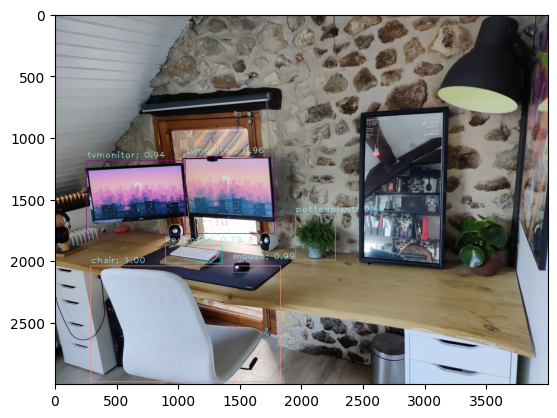

In [14]:
plt.imshow(img[:,:,::-1])

In [15]:
# open('coco.names').read().strip().split('\n')[56]

Save it into an image folder present in our source folder

In [16]:
cv2.imwrite("output.jpg", img)

True

Running this command will show the image in a separate Screen (to close the window, Press any Key instead of closing by clicking X on the right top of the image)

In [17]:
# cv2.imshow("Image_name",img)
# cv2.waitKey()
# cv2.destroyAllWindows()


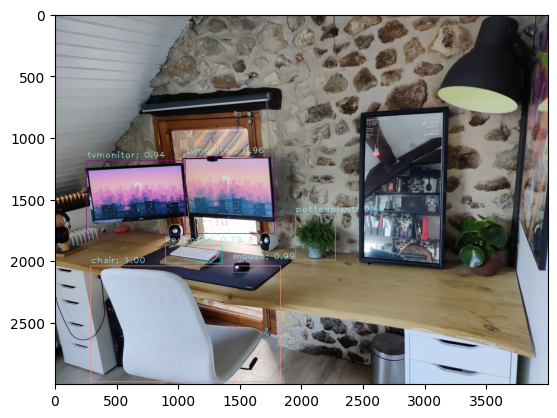

In [18]:
new_image = img.copy()

plt.imshow(new_image[:,:,::-1])

In [19]:
new_image.shape[0]

3000

In [20]:
# bbox = [895, 1874, 461, 145]

In [21]:
# # Importing Image class from PIL module
# from PIL import Image
 
# # Opens a image in RGB mode
# im = Image.open(r"output.jpg")
 
# # Size of the image in pixels (size of original image)
# # (This is not mandatory)
# width, height = im.size
# im.size

In [22]:
# # Setting the points for cropped image
# left = 895
# top = 1874
# right = 895 + 461
# bottom = 1874 + 145
 
# # Cropped image of above dimension
# # (It will not change original image)
# im1 = im.crop((left, top, right, bottom))
 

# im1


In [23]:
# im1.save('myimage_cropped.jpg')
# im1.show()